# Reporting Descriptive Statistics in Clinical Research

**Authors:** Renato Carneiro de Freitas Chaves, Tiago Mendonça dos Santos, Thiago Domingos Corrêa  
**Notebook version:** Python implementation

---

## 1) Purpose

This Jupyter Notebook provides a step-by-step analytical structure for clinical research comparing:

- **Control group** (`group = 0`)
- **Intervention group** (`group = 1`)

Using the accompanying dataset, it demonstrates how to:

1. Prepare an analysis-ready dataset for descriptive reporting.
2. Summarize **continuous variables** using measures of central tendency and dispersion.
3. Summarize **categorical variables** using counts and proportions.
4. Create tables and visual displays commonly used in epidemiological and clinical research.
5. Organize descriptive results in a format suitable for academic and scientific reporting.

The descriptive examples use:

- **Grouping variable:** `group`
- **Binary clinical outcome:** `outcome`
- **Continuous baseline and laboratory variables**, such as `age`, `platelet`, `hemoglobin`, `creatinine`, `saps_3`, and `fluid_balance`
- **Binary comorbidity and support variables**, such as `hypertension`, `diabetes`, `heart_failure`, `smoking`, `chronic_kidney_disease`, `cancer`, `stroke`, `vasopressor`, and `mechanical_ventilation`

> **Dataset coding (according to the model data file)**  
> - `group`: `0 = Control`, `1 = Intervention`  
> - `outcome`: `0 = Alive`, `1 = Dead`


## 2) Python libraries

This notebook uses standard scientific Python libraries for data management, descriptive statistics, and graphical presentation.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 120)


## 3) Data Import (Excel)

This guide uses the Excel file **`data.xlsx`** with a worksheet named **`Data`**.

- If `data.xlsx` is in the same folder as this notebook, keep the path as `"data.xlsx"`.
- Otherwise, replace it with the full path to your file.


In [2]:
data = pd.read_excel("data.xlsx", sheet_name="Data")
data.head()


,patient,group,center,age,platelet,hemoglobin,creatinine,hypertension,diabetes,heart_failure,smoking,chronic_kidney_disease,cancer,stroke,saps_3,vasopressor,mechanical_ventilation,fluid_balance,outcome
0,1,1,1,19,229,15.3,0.8,0,0,0,0,0,0,0,5,0,0,-956,0
1,2,1,1,24,221,14.8,0.8,0,0,0,0,0,0,0,8,0,0,-3600,0
2,3,1,1,25,219,14.4,0.9,0,0,0,0,0,0,0,10,0,0,-820,0
3,4,1,1,26,217,14.3,0.9,0,0,0,0,0,0,0,18,0,0,-660,0
4,5,1,1,27,214,13.8,0.9,1,0,1,0,1,1,0,19,1,0,-600,0


## 4) Confirm Required Variables

For the proposed descriptive analyses, we need:

- `group` (`0 = Control`, `1 = Intervention`)
- `outcome` (`0 = Alive`, `1 = Dead`)
- a set of continuous variables for numerical summaries
- a set of binary or categorical variables for frequency summaries


In [5]:
# General structure
print("Dataset shape:", data.shape)
print("\nVariable types:")
display(data.dtypes.to_frame("dtype"))

print("\nMissing values by variable:")
display(data.isna().sum().to_frame("missing_values"))

print("\nFrequency distribution of the outcome variable:")
display(data["outcome"].value_counts(dropna=False).rename_axis("outcome").reset_index(name="n"))


Dataset shape: (50, 19)

Variable types:


,dtype
patient,int64
group,int64
center,int64
age,int64
platelet,int64
hemoglobin,float64
creatinine,float64
hypertension,int64
diabetes,int64
heart_failure,int64



Missing values by variable:


,missing_values
patient,0
group,0
center,0
age,0
platelet,0
hemoglobin,0
creatinine,0
hypertension,0
diabetes,0
heart_failure,0



Frequency distribution of the outcome variable:


,outcome,n
0,1,30
1,0,20


## 5) Create the Analysis Dataset

We will:

- define the continuous and binary variables of interest
- keep only rows with non-missing `group` and `outcome`
- ensure continuous variables are numeric
- ensure binary variables are coded consistently
- create labeled categories for descriptive presentation


In [4]:
# --- Continuous variables ---

numerical_vars = [
    "age",
    "platelet",
    "hemoglobin",
    "creatinine",
    "saps_3",
    "fluid_balance",
]

# --- Binary/categorical variables ---
binary_vars = [
    "group",
    "hypertension",
    "diabetes",
    "heart_failure",
    "smoking",
    "chronic_kidney_disease",
    "cancer",
    "stroke",
    "vasopressor",
    "mechanical_ventilation",
    "outcome",
]

required_vars = numerical_vars + binary_vars

analysis_data = data.loc[:, required_vars].copy()
analysis_data = analysis_data.loc[
    analysis_data["group"].notna() & analysis_data["outcome"].notna()
].copy()

for col in numerical_vars:
    analysis_data[col] = pd.to_numeric(analysis_data[col], errors="coerce")

for col in binary_vars:
    analysis_data[col] = pd.to_numeric(analysis_data[col], errors="coerce").astype("Int64")

analysis_data["group_label"] = analysis_data["group"].map({0: "Control", 1: "Intervention"})
analysis_data["outcome_label"] = analysis_data["outcome"].map({0: "Alive", 1: "Dead"})

other_binary_vars = [col for col in binary_vars if col not in ["group", "outcome"]]
for col in other_binary_vars:
    analysis_data[f"{col}_label"] = analysis_data[col].map({0: "No", 1: "Yes"})

analysis_data.head()


,age,platelet,hemoglobin,creatinine,saps_3,fluid_balance,group,hypertension,diabetes,heart_failure,smoking,chronic_kidney_disease,cancer,stroke,vasopressor,mechanical_ventilation,outcome,group_label,outcome_label,hypertension_label,diabetes_label,heart_failure_label,smoking_label,chronic_kidney_disease_label,cancer_label,stroke_label,vasopressor_label,mechanical_ventilation_label
0,19,229,15.3,0.8,5,-956,1,0,0,0,0,0,0,0,0,0,0,Intervention,Alive,No,No,No,No,No,No,No,No,No
1,24,221,14.8,0.8,8,-3600,1,0,0,0,0,0,0,0,0,0,0,Intervention,Alive,No,No,No,No,No,No,No,No,No
2,25,219,14.4,0.9,10,-820,1,0,0,0,0,0,0,0,0,0,0,Intervention,Alive,No,No,No,No,No,No,No,No,No
3,26,217,14.3,0.9,18,-660,1,0,0,0,0,0,0,0,0,0,0,Intervention,Alive,No,No,No,No,No,No,No,No,No
4,27,214,13.8,0.9,19,-600,1,1,0,1,0,1,1,0,1,0,0,Intervention,Alive,Yes,No,Yes,No,Yes,Yes,No,Yes,No


In [5]:
print("Final analysis dataset shape:", analysis_data.shape)
print("\nFinal variable types:")
display(analysis_data.dtypes.to_frame("dtype"))


Final analysis dataset shape: (50, 28)

Final variable types:


,dtype
age,int64
platelet,int64
hemoglobin,float64
creatinine,float64
saps_3,int64
fluid_balance,int64
group,Int64
hypertension,Int64
diabetes,Int64
heart_failure,Int64


## 6) Descriptive Reporting for Categorical Variables

### 6.1 Frequency Tables and Proportions

This section summarizes the distribution of categorical variables using:

- **absolute frequencies (`n`)**
- **relative frequencies (`%`)**
- **contingency tables** when comparisons across groups are relevant


In [6]:
# Contingency table: group versus outcome
tab_group_outcome = pd.crosstab(
    analysis_data["group_label"],
    analysis_data["outcome_label"],
    dropna=False
)

print("Contingency table: Group versus Outcome")
display(tab_group_outcome)

print("Row proportions: within-group outcome distribution")
display(tab_group_outcome.div(tab_group_outcome.sum(axis=1), axis=0).round(4))


Contingency table: Group versus Outcome


outcome_label,Alive,Dead
group_label,,
Control,6,19
Intervention,14,11


Row proportions: within-group outcome distribution


outcome_label,Alive,Dead
group_label,,
Control,0.24,0.76
Intervention,0.56,0.44


In [7]:
# Example: group versus hypertension
tab_group_htn = pd.crosstab(
    analysis_data["group_label"],
    analysis_data["hypertension_label"],
    dropna=False
)

print("Contingency table: Group versus Hypertension")
display(tab_group_htn)

print("Row proportions: within-group hypertension distribution")
display(tab_group_htn.div(tab_group_htn.sum(axis=1), axis=0).round(4))


Contingency table: Group versus Hypertension


hypertension_label,No,Yes
group_label,,
Control,7,18
Intervention,9,16


Row proportions: within-group hypertension distribution


hypertension_label,No,Yes
group_label,,
Control,0.28,0.72
Intervention,0.36,0.64


## 7) Descriptive Reporting for Continuous Variables

This section summarizes continuous variables using:

- **mean** and **standard deviation (SD)**
- **median** and **interquartile range (IQR)**
- **minimum** and **maximum**


### 7.1 Continuous-Variable Summary by Group


In [8]:
def summarize_continuous(series: pd.Series) -> pd.Series:
    x = pd.to_numeric(series, errors="coerce").dropna()
    return pd.Series({
        "n": x.size,
        "mean": x.mean(),
        "sd": x.std(ddof=1),
        "median": x.median(),
        "q1": x.quantile(0.25),
        "q3": x.quantile(0.75),
        "min": x.min(),
        "max": x.max(),
    })

continuous_summary = (
    analysis_data
    .groupby("group_label")[numerical_vars]
    .apply(lambda df: df.apply(summarize_continuous))
)

continuous_summary


age    platelet  hemoglobin  creatinine     saps_3  fluid_balance
group_label                                                                                 
Control      n       25.000000   25.000000   25.000000   25.000000  25.000000      25.000000
             mean    61.240000  110.160000    9.412000    3.208000  59.000000    1919.720000
             sd      11.896358   20.403594    1.037754    1.099591  10.866616     908.587802
             median  58.000000  108.000000    9.300000    3.200000  56.000000    1440.000000
             q1      52.000000   92.000000    8.700000    2.100000  49.000000    1410.000000
             q3      71.000000  125.000000   10.200000    4.000000  67.000000    2020.000000
             min     45.000000   80.000000    6.800000    1.700000  47.000000    1322.000000
             max     85.000000  147.000000   11.000000    5.000000  82.000000    5349.000000
Intervention n       25.000000   25.000000   25.000000   25.000000  25.000000      25.000000
             mean    31.200000  191.120000   12.472000    1.256000  30.280000      75.400000
             sd       6.467869   22.783986    1.243825    0.291662  11.674474    1002.461637
             median  29.000000  192.000000   12.200000    1.300000  32.000000     276.000000
             q1      27.000000  171.000000   11.500000    1.000000  25.000000    -400.000000
             q3      35.000000  211.000000   13.100000    1.500000  37.000000     576.000000
             min     19.000000  151.000000   11.000000    0.800000   5.000000   -3600.000000
             max     45.000000  229.000000   15.300000    1.700000  47.000000    1300.000000

### 7.2 Stratified Descriptive Table for Publication or Reporting


In [9]:
def format_continuous(series: pd.Series) -> str:
    x = pd.to_numeric(series, errors="coerce").dropna()
    if x.empty:
        return "NA"
    return (
        f"{x.mean():.2f} ({x.std(ddof=1):.2f}); "
        f"{x.median():.2f} ({x.quantile(0.25):.2f}, {x.quantile(0.75):.2f}); "
        f"min {x.min():.2f}, max {x.max():.2f}"
    )

def format_categorical(series: pd.Series) -> str:
    x = series.dropna()
    if x.empty:
        return "NA"
    counts = x.value_counts(dropna=False)
    total = counts.sum()
    parts = [f"{category}: {count} ({100 * count / total:.1f}%)" for category, count in counts.items()]
    return "; ".join(parts)

table_rows = []

# Categorical variables
for var in ["outcome_label"] + [f"{v}_label" for v in other_binary_vars]:
    row = {
        "Variable": var.replace("_label", "").replace("_", " ").title(),
        "Control": format_categorical(analysis_data.loc[analysis_data["group_label"] == "Control", var]),
        "Intervention": format_categorical(analysis_data.loc[analysis_data["group_label"] == "Intervention", var]),
        "Overall": format_categorical(analysis_data[var]),
    }
    table_rows.append(row)

# Continuous variables
for var in numerical_vars:
    row = {
        "Variable": var.replace("_", " ").title(),
        "Control": format_continuous(analysis_data.loc[analysis_data["group_label"] == "Control", var]),
        "Intervention": format_continuous(analysis_data.loc[analysis_data["group_label"] == "Intervention", var]),
        "Overall": format_continuous(analysis_data[var]),
    }
    table_rows.append(row)

descriptive_table = pd.DataFrame(table_rows)
descriptive_table


,Variable,Control,Intervention,Overall
0,Outcome,Dead: 19 (76.0%); Alive: 6 (24.0%),Alive: 14 (56.0%); Dead: 11 (44.0%),Dead: 30 (60.0%); Alive: 20 (40.0%)
1,Hypertension,Yes: 18 (72.0%); No: 7 (28.0%),Yes: 16 (64.0%); No: 9 (36.0%),Yes: 34 (68.0%); No: 16 (32.0%)
2,Diabetes,Yes: 16 (64.0%); No: 9 (36.0%),No: 15 (60.0%); Yes: 10 (40.0%),Yes: 26 (52.0%); No: 24 (48.0%)
3,Heart Failure,Yes: 13 (52.0%); No: 12 (48.0%),No: 19 (76.0%); Yes: 6 (24.0%),No: 31 (62.0%); Yes: 19 (38.0%)
4,Smoking,Yes: 13 (52.0%); No: 12 (48.0%),No: 19 (76.0%); Yes: 6 (24.0%),No: 31 (62.0%); Yes: 19 (38.0%)
5,Chronic Kidney Disease,Yes: 18 (72.0%); No: 7 (28.0%),Yes: 16 (64.0%); No: 9 (36.0%),Yes: 34 (68.0%); No: 16 (32.0%)
6,Cancer,Yes: 16 (64.0%); No: 9 (36.0%),No: 13 (52.0%); Yes: 12 (48.0%),Yes: 28 (56.0%); No: 22 (44.0%)
7,Stroke,Yes: 15 (60.0%); No: 10 (40.0%),No: 17 (68.0%); Yes: 8 (32.0%),No: 27 (54.0%); Yes: 23 (46.0%)
8,Vasopressor,Yes: 18 (72.0%); No: 7 (28.0%),Yes: 13 (52.0%); No: 12 (48.0%),Yes: 31 (62.0%); No: 19 (38.0%)
9,Mechanical Ventilation,Yes: 16 (64.0%); No: 9 (36.0%),No: 15 (60.0%); Yes: 10 (40.0%),Yes: 26 (52.0%); No: 24 (48.0%)


## 8) Graphical Display of the Data

Visual summaries complement numerical summaries and help assess shape, skewness, variability, and outliers.


### 8.1 Histograms


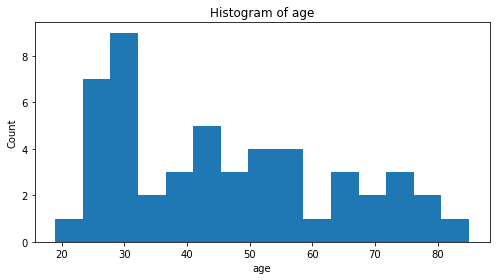

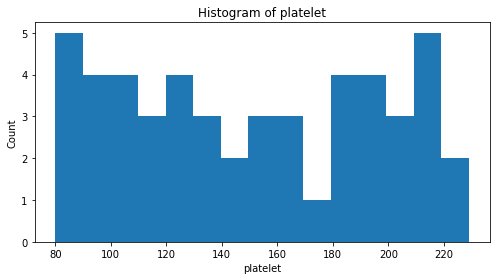

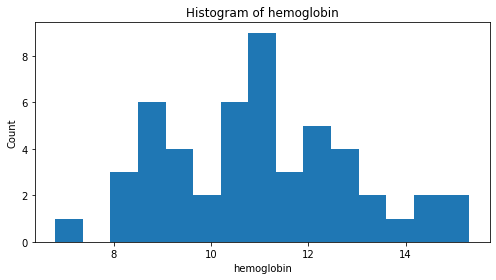

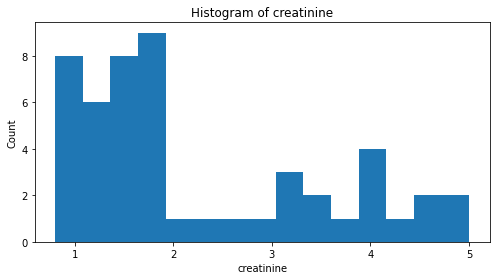

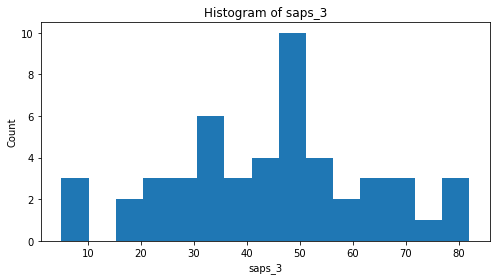

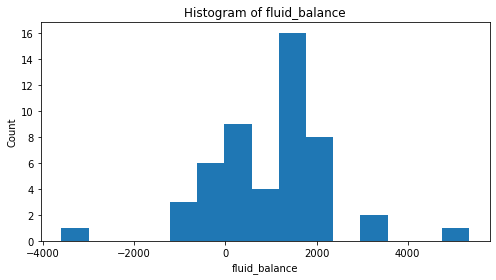

In [21]:
for var in numerical_vars:
    plt.figure(figsize=(7, 4))
    plt.hist(analysis_data[var].dropna(), bins=15)
    plt.title(f"Histogram of {var}")
    plt.xlabel(var)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


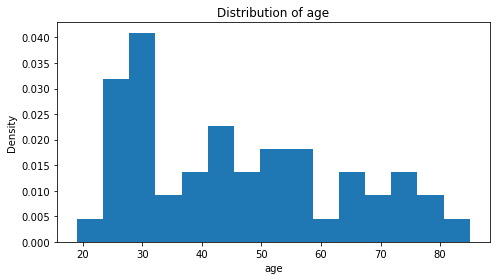

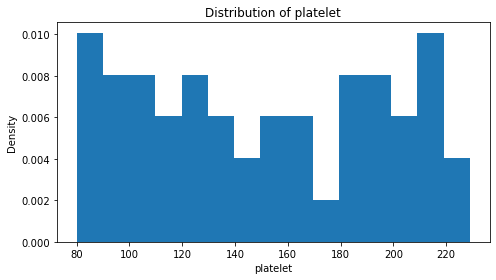

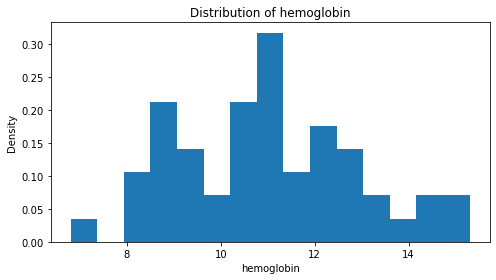

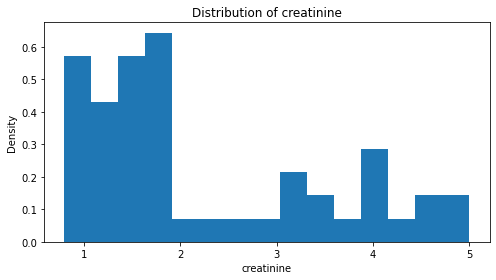

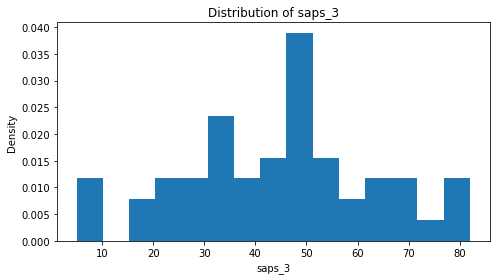

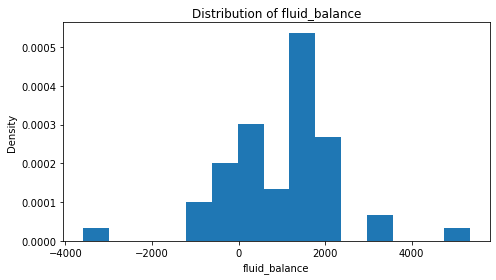

In [22]:
for var in numerical_vars:
    x = analysis_data[var].dropna()
    plt.figure(figsize=(7, 4))
    plt.hist(x, bins=15, density=True)
    plt.title(f"Distribution of {var}")
    plt.xlabel(var)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()


### 8.3 Box Plots (Overall and by Group)


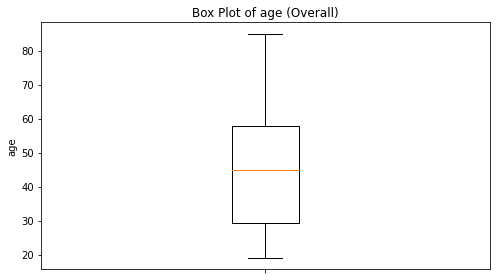

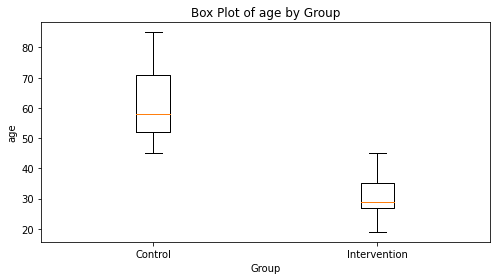

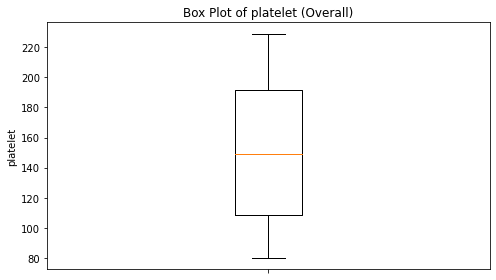

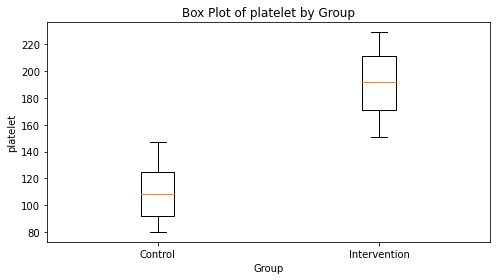

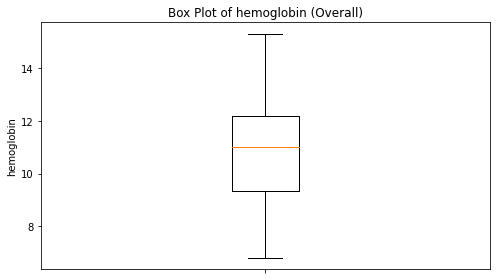

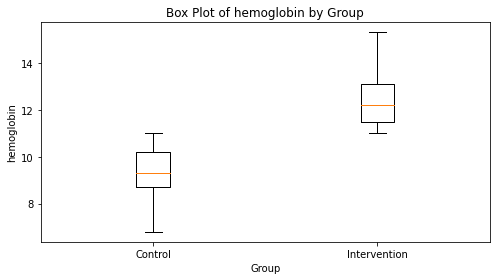

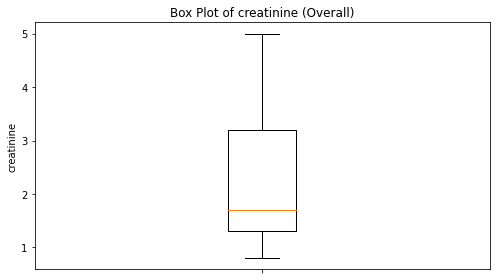

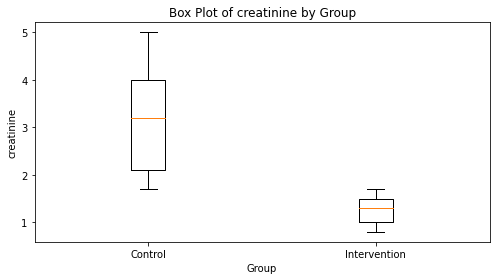

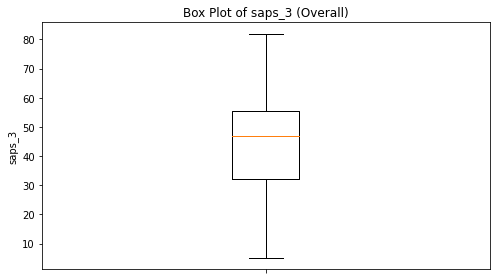

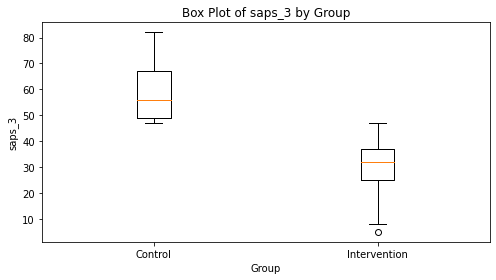

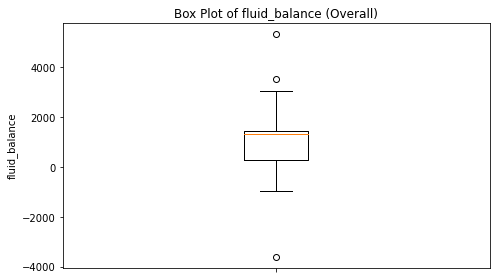

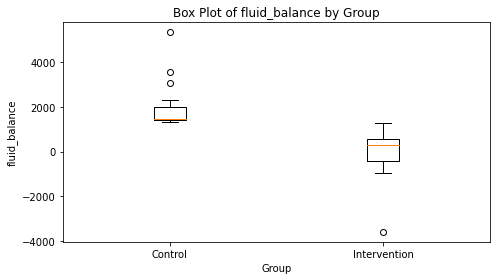

In [25]:
for var in numerical_vars:
    # Overall box plot
    plt.figure(figsize=(7, 4))
    plt.boxplot(analysis_data[var].dropna(), vert=True)
    plt.title(f"Box Plot of {var} (Overall)")
    plt.ylabel(var)
    plt.xticks([1], [""])
    plt.tight_layout()
    plt.show()

    # By-group box plot
    control_values = analysis_data.loc[
        analysis_data["group_label"] == "Control", var
    ].dropna()

    intervention_values = analysis_data.loc[
        analysis_data["group_label"] == "Intervention", var
    ].dropna()

    plt.figure(figsize=(7, 4))
    plt.boxplot(
        [control_values, intervention_values],
        labels=["Control", "Intervention"]  # <- fix here
    )
    plt.title(f"Box Plot of {var} by Group")
    plt.xlabel("Group")
    plt.ylabel(var)
    plt.tight_layout()
    plt.show()

## 9) Graphical Display for Categorical Variables

Pie charts can illustrate category composition, although bar charts are often preferred in scientific reporting.

### 9.1 Mathematical Definition

For category $c$, the slice size corresponds to the proportion $p_c$, with percentage equal to $100 \times p_c$.


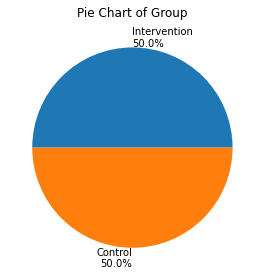

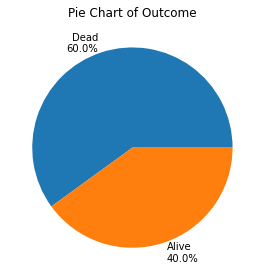

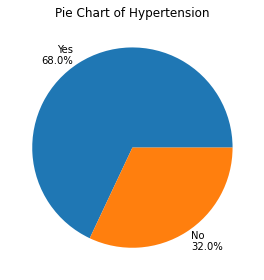

In [26]:
def plot_pie(series: pd.Series, title: str) -> None:
    counts = series.dropna().value_counts()
    labels = [
        f"{category}\n{100 * count / counts.sum():.1f}%"
        for category, count in counts.items()
    ]

    plt.figure(figsize=(7, 4))
    plt.pie(counts.values, labels=labels)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_pie(analysis_data["group_label"], "Pie Chart of Group")
plot_pie(analysis_data["outcome_label"], "Pie Chart of Outcome")
plot_pie(analysis_data["hypertension_label"], "Pie Chart of Hypertension")


## End of Notebook